# Лабораторная работа №4: Поиск ассоциативных правил в транзакционных данных

**Датасет:** Market Basket Optimisation
**Описание:** Набор транзакционных данных из розничного магазина — каждая строка представляет собой чек (корзину покупок), содержащий список купленных товаров.

**Цель:** Освоить методы поиска ассоциативных правил, реализовать алгоритмы Apriori и FP-Growth «с нуля», применить их к реальным и синтетическим данным, сравнить производительность и интерпретировать результаты.

## Импорт библиотек и настройка окружения

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import time
import random
from itertools import combinations, chain
from collections import defaultdict, OrderedDict
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
PALETTE = 'tab10'

# Фиксируем seed для воспроизводимости
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Все библиотеки загружены.")

Все библиотеки загружены.


---
## Задание 1. Реализация алгоритма Apriori

In [26]:
def apriori_gen(prev_frequent_items, k):

    candidates = set()
    prev_list = sorted(prev_frequent_items)
    n = len(prev_list)
    
    for i in range(n):
        for j in range(i + 1, n):
            # Объединяем, если первые k-2 элементов совпадают
            l1 = list(prev_list[i])
            l2 = list(prev_list[j])
            
            if l1[:k-2] == l2[:k-2]:
                candidate = frozenset(prev_list[i]) | frozenset(prev_list[j])
                if len(candidate) == k:
                    # Проверка: все подмножества размера k-1 должны быть частыми
                    prev_set = set(map(frozenset, prev_list))
                    all_subsets_frequent = True
                    for item in candidate:
                        subset = candidate - frozenset([item])
                        if subset not in prev_set:
                            all_subsets_frequent = False
                            break
                    if all_subsets_frequent:
                        candidates.add(candidate)
    
    return candidates


def apriori(transactions, min_support):
 
    n_transactions = len(transactions)
    min_count = min_support * n_transactions
    
    # Этап 1: одиночные элементы
    item_counts = defaultdict(int)
    for t in transactions:
        for item in t:
            item_counts[frozenset([item])] += 1
    
    # Фильтрация по min_support
    current_frequent = {
        item: count for item, count in item_counts.items() 
        if count >= min_count
    }
    
    # Результат: все частые наборы
    all_frequent = {}
    for itemset, count in current_frequent.items():
        key = tuple(sorted(itemset))
        all_frequent[key] = count / n_transactions
    
    k = 2
    while current_frequent:
        # Преобразуем ключи в отсортированные кортежи для генерации кандидатов
        prev_keys = [tuple(sorted(fs)) for fs in current_frequent.keys()]
        
        # Генерация кандидатов
        candidates = apriori_gen(prev_keys, k)
        
        if not candidates:
            break
        
        # Подсчёт поддержки кандидатов
        candidate_counts = defaultdict(int)
        for t in transactions:
            for candidate in candidates:
                if candidate.issubset(t):
                    candidate_counts[candidate] += 1
        
        # Фильтрация по min_support
        current_frequent = {
            candidate: count for candidate, count in candidate_counts.items()
            if count >= min_count
        }
        
        # Сохраняем в общий результат
        for itemset, count in current_frequent.items():
            key = tuple(sorted(itemset))
            all_frequent[key] = count / n_transactions
        
        k += 1
    
    return all_frequent


print("Функция apriori() реализована.")

Функция apriori() реализована.


In [27]:
def generate_rules(frequent_itemsets, min_confidence, min_lift=1.0,
                   max_antecedent_len=None, max_consequent_len=None):

    rules = []
    
    for itemset_tuple, support in frequent_itemsets.items():
        itemset = frozenset(itemset_tuple)
        k = len(itemset)
        
        if k < 2:
            continue
        
        # Генерируем все непустые собственные подмножества
        for i in range(1, k):
            for antecedent_tuple in combinations(sorted(itemset), i):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent
                
                # Проверяем ограничения на длину
                if max_antecedent_len is not None and len(antecedent) > max_antecedent_len:
                    continue
                if max_consequent_len is not None and len(consequent) > max_consequent_len:
                    continue
                
                # Поддержки
                ant_key = tuple(sorted(antecedent))
                con_key = tuple(sorted(consequent))
                
                if ant_key not in frequent_itemsets or con_key not in frequent_itemsets:
                    continue
                
                support_ant = frequent_itemsets[ant_key]
                support_con = frequent_itemsets[con_key]
                
                # Метрики
                confidence = support / support_ant
                
                if confidence < min_confidence:
                    continue
                
                lift = confidence / support_con if support_con > 0 else float('inf')
                
                if lift < min_lift:
                    continue
                
                # Conviction
                if confidence == 1.0:
                    conviction = float('inf')
                else:
                    conviction = (1 - support_con) / (1 - confidence)
                
                # Leverage
                leverage = support - (support_ant * support_con)
                
                rules.append((
                    tuple(sorted(antecedent)),
                    tuple(sorted(consequent)),
                    round(support, 6),
                    round(confidence, 6),
                    round(lift, 6),
                    round(conviction, 6) if conviction != float('inf') else float('inf'),
                    round(leverage, 6)
                ))
    
    return rules


print("Функция generate_rules() реализована.")

Функция generate_rules() реализована.


In [10]:
# Тест Apriori на основном датасете
print("Запуск Apriori с min_support=0.03...")
t_start = time.time()
freq_apriori = apriori(transactions, min_support=0.03)
t_apriori = time.time() - t_start
print(f"Время выполнения: {t_apriori:.2f} сек.")
print(f"Найдено частых наборов: {len(freq_apriori)}")

# Топ-10 по поддержке
sorted_freq = sorted(freq_apriori.items(), key=lambda x: x[1], reverse=True)
print("\nТоп-10 частых наборов по поддержке:")
for itemset, sup in sorted_freq[:10]:
    print(f"  {itemset}: {sup:.4f}")

Запуск Apriori с min_support=0.03...
Время выполнения: 0.00 сек.
Найдено частых наборов: 3

Топ-10 частых наборов по поддержке:
  ('1',): 0.9990
  ('0',): 0.9990
  ('0', '1'): 0.9990


In [11]:
# Генерация правил (Apriori)
rules_apriori = generate_rules(freq_apriori, min_confidence=0.3, min_lift=1.0)
print(f"\nНайдено правил: {len(rules_apriori)}")

# Вывод правил
if rules_apriori:
    rules_df = pd.DataFrame(rules_apriori, 
                             columns=['Antecedent', 'Consequent', 'Support', 
                                      'Confidence', 'Lift', 'Conviction', 'Leverage'])
    rules_df = rules_df.sort_values('Lift', ascending=False)
    print("\nТоп-10 правил по Lift (Apriori):")
    display(rules_df.head(10))
else:
    print("Правил не найдено. Попробуем снизить пороги.")


Найдено правил: 2

Топ-10 правил по Lift (Apriori):


,Antecedent,Consequent,Support,Confidence,Lift,Conviction,Leverage
0,"(0,)","(1,)",0.999,1.0,1.001001,inf,0.000999
1,"(1,)","(0,)",0.999,1.0,1.001001,inf,0.000999


---
## Задание 2. Реализация FP-Growth

In [39]:
class FPNode:
   
    def __init__(self, item=None, count=0, parent=None):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None
    
    def increment(self, count=1):
        """Увеличить счётчик узла."""
        self.count += count
    
    def __repr__(self):
        return f"FPNode(item={self.item}, count={self.count})"


class FPTree:

    def __init__(self, transactions, min_support_count, item_order=None):

        self.root = FPNode()
        self.header_table = OrderedDict()
        self.min_support_count = min_support_count
        
        if item_order is not None:
            self.item_counts = item_order
        else:
            # Подсчёт частот элементов
            self.item_counts = defaultdict(int)
            for t in transactions:
                if isinstance(t, tuple):
                    items, count = t
                else:
                    items, count = t, 1
                for item in items:
                    self.item_counts[item] += count
        
        # Фильтрация: оставляем только элементы с поддержкой >= min_support_count
        self.frequent_items = {
            item: count for item, count in self.item_counts.items()
            if count >= min_support_count
        }
        
        # Инициализация header table (в порядке убывания частоты)
        sorted_items = sorted(self.frequent_items.items(), key=lambda x: (-x[1], x[0]))
        for item, count in sorted_items:
            self.header_table[item] = [count, None]  # [count, first_node_link]
        
        # Вставка транзакций
        for t in transactions:
            if isinstance(t, tuple):
                items, count = t
            else:
                items, count = t, 1
            
            # Фильтруем и сортируем по убыванию частоты
            filtered = [item for item in items if item in self.frequent_items]
            filtered.sort(key=lambda x: (-self.frequent_items[x], x))
            
            if filtered:
                self._insert_tree(filtered, self.root, count)
    
    def _insert_tree(self, items, node, count):
        if not items:
            return
        
        first_item = items[0]
        
        if first_item in node.children:
            # Узел уже существует — увеличиваем счётчик
            child = node.children[first_item]
            child.increment(count)
        else:
            # Создаём новый узел
            child = FPNode(item=first_item, count=count, parent=node)
            node.children[first_item] = child
            
            # Обновляем горизонтальные ссылки в header table
            self._update_header(first_item, child)
        
        # Рекурсивно вставляем оставшиеся элементы
        self._insert_tree(items[1:], child, count)
    
    def _update_header(self, item, target_node):
        if self.header_table[item][1] is None:
            self.header_table[item][1] = target_node
        else:
            current = self.header_table[item][1]
            while current.node_link is not None:
                current = current.node_link
            current.node_link = target_node
    
    def _prefix_paths(self, item):
   
        paths = []
        node = self.header_table[item][1]
        
        while node is not None:
            prefix = []
            parent = node.parent
            while parent.item is not None:
                prefix.append(parent.item)
                parent = parent.parent
            if prefix:
                paths.append((prefix, node.count))
            node = node.node_link
        
        return paths
    
    def is_single_path(self):
        node = self.root
        while node.children:
            if len(node.children) > 1:
                return False
            node = list(node.children.values())[0]
        return True
    
    def get_single_path_items(self):
        items = []
        node = self.root
        while node.children:
            child = list(node.children.values())[0]
            items.append((child.item, child.count))
            node = child
        return items


def fpgrowth(transactions, min_support):

    n_transactions = len(transactions)
    min_support_count = min_support * n_transactions
    
    frequent_itemsets = {}
    
    def _fpgrowth_recursive(tree, prefix, min_count):
        
        if tree.is_single_path():
            # Если дерево — единственный путь, генерируем все комбинации
            path_items = tree.get_single_path_items()
            
            for i in range(1, len(path_items) + 1):
                for combo in combinations(path_items, i):
                    items = frozenset([item for item, _ in combo])
                    count = min(c for _, c in combo)
                    
                    pattern = items | prefix
                    key = tuple(sorted(pattern))
                    support = count / n_transactions
                    
                    if count >= min_count:
                        frequent_itemsets[key] = support
        else:
            # Обрабатываем каждый элемент в header table (в обратном порядке)
            items_list = list(tree.header_table.keys())
            
            for item in reversed(items_list):
                # Новый паттерн = prefix + item
                new_pattern = prefix | frozenset([item])
                support = tree.header_table[item][0] / n_transactions
                
                if tree.header_table[item][0] >= min_count:
                    key = tuple(sorted(new_pattern))
                    frequent_itemsets[key] = support
                
                # Строим conditional pattern base
                prefix_paths = tree._prefix_paths(item)
                
                if prefix_paths:
                    # Строим conditional FP-tree
                    cond_transactions = []
                    cond_item_counts = defaultdict(int)
                    
                    for path, count in prefix_paths:
                        for path_item in path:
                            cond_item_counts[path_item] += count
                        cond_transactions.append((frozenset(path), count))
                    
                    # Фильтруем нечастые элементы
                    cond_item_counts = {
                        k: v for k, v in cond_item_counts.items() 
                        if v >= min_count
                    }
                    
                    if cond_item_counts:
                        cond_tree = FPTree(
                            cond_transactions, 
                            min_count, 
                            item_order=cond_item_counts
                        )
                        
                        if cond_tree.header_table:
                            _fpgrowth_recursive(cond_tree, new_pattern, min_count)
    
    # Строим начальное FP-дерево
    tree = FPTree(transactions, min_support_count)
    
    # Добавляем одиночные частые элементы
    for item, (count, _) in tree.header_table.items():
        if count >= min_support_count:
            key = (item,)
            frequent_itemsets[key] = count / n_transactions
    
    # Запускаем рекурсивный рост
    _fpgrowth_recursive(tree, frozenset(), min_support_count)
    
    return frequent_itemsets


print("Алгоритм FP-Growth реализован.")

Алгоритм FP-Growth реализован.


In [40]:
# Тест FP-Growth на основном датасете
print("Запуск FP-Growth с min_support=0.03...")
t_start = time.time()
freq_fpgrowth = fpgrowth(transactions, min_support=0.03)
t_fpgrowth = time.time() - t_start
print(f"Время выполнения: {t_fpgrowth:.2f} сек.")
print(f"Найдено частых наборов: {len(freq_fpgrowth)}")

# Топ-10 по поддержке
sorted_freq_fp = sorted(freq_fpgrowth.items(), key=lambda x: x[1], reverse=True)
print("\nТоп-10 частых наборов по поддержке (FP-Growth):")
for itemset, sup in sorted_freq_fp[:10]:
    print(f"  {itemset}: {sup:.4f}")

Запуск FP-Growth с min_support=0.03...
Время выполнения: 0.01 сек.
Найдено частых наборов: 19

Топ-10 частых наборов по поддержке (FP-Growth):
  ('whole milk',): 0.1407
  ('soda',): 0.1266
  ('rolls/buns',): 0.1261
  ('other vegetables',): 0.0870
  ('canned beer',): 0.0822
  ('bottled beer',): 0.0665
  ('bottled water',): 0.0665
  ('yogurt',): 0.0629
  ('pastry',): 0.0504
  ('newspapers',): 0.0485


In [41]:
# Сравнение результатов Apriori и FP-Growth
print("=== Сравнение результатов Apriori и FP-Growth ===")
print(f"Apriori: {len(freq_apriori)} частых наборов")
print(f"FP-Growth: {len(freq_fpgrowth)} частых наборов")

# Проверяем совпадение
apriori_keys = set(freq_apriori.keys())
fpgrowth_keys = set(freq_fpgrowth.keys())

common = apriori_keys & fpgrowth_keys
only_apriori = apriori_keys - fpgrowth_keys
only_fpgrowth = fpgrowth_keys - apriori_keys

print(f"\nОбщие: {len(common)}")
print(f"Только в Apriori: {len(only_apriori)}")
print(f"Только в FP-Growth: {len(only_fpgrowth)}")

if only_apriori:
    print("Примеры наборов только в Apriori:", list(only_apriori)[:5])
if only_fpgrowth:
    print("Примеры наборов только в FP-Growth:", list(only_fpgrowth)[:5])

=== Сравнение результатов Apriori и FP-Growth ===
Apriori: 3 частых наборов
FP-Growth: 19 частых наборов

Общие: 0
Только в Apriori: 3
Только в FP-Growth: 19
Примеры наборов только в Apriori: [('0',), ('1',), ('0', '1')]
Примеры наборов только в FP-Growth: [('shopping bags',), ('tropical fruit',), ('pip fruit',), ('root vegetables',), ('bottled water',)]


In [42]:
# Генерация правил с FP-Growth (используем универсальную функцию)
rules_fpgrowth = generate_rules(freq_fpgrowth, min_confidence=0.3, min_lift=1.0)
print(f"Найдено правил (FP-Growth): {len(rules_fpgrowth)}")

if rules_fpgrowth:
    rules_fp_df = pd.DataFrame(rules_fpgrowth,
                                columns=['Antecedent', 'Consequent', 'Support',
                                         'Confidence', 'Lift', 'Conviction', 'Leverage'])
    rules_fp_df = rules_fp_df.sort_values('Lift', ascending=False)
    print("\nТоп-10 правил по Lift (FP-Growth):")
    display(rules_fp_df.head(10))

Найдено правил (FP-Growth): 0



### Задание 3. Выбор и загрузка реального датасета

In [43]:
# Загрузка датасета
raw_df = pd.read_csv('C:\\Users\\му-рс\\OneDrive\\Рабочий стол\\vsc workspaces\\lab4\\data\\groceries.csv', header=None, on_bad_lines='skip')
print(f"Размер таблицы: {raw_df.shape}")
raw_df.head()

Размер таблицы: (6106, 4)


,0,1,2,3
0,citrus fruit,semi-finished bread,margarine,ready soups
1,tropical fruit,yogurt,coffee,NaN
2,whole milk,NaN,NaN,NaN
3,pip fruit,yogurt,cream cheese,meat spreads
4,other vegetables,whole milk,condensed milk,long life bakery product


In [44]:
transactions = []
for i in range(len(raw_df)):
    row = raw_df.iloc[i]
    items = set()
    for val in row:
        if pd.notna(val):
            item = str(val).strip().lower()
            if item:
                items.add(item)
    if items:  # только непустые транзакции
        transactions.append(frozenset(items))

print(f"Количество транзакций: {len(transactions)}")

Количество транзакций: 6106


In [45]:
# Базовая статистика
all_items = set()
lengths = []
for t in transactions:
    all_items.update(t)
    lengths.append(len(t))

print(f"Количество уникальных элементов: {len(all_items)}")
print(f"Средняя длина транзакции: {np.mean(lengths):.2f}")
print(f"Медианная длина транзакции: {np.median(lengths):.1f}")
print(f"Минимальная длина транзакции: {np.min(lengths)}")
print(f"Максимальная длина транзакции: {np.max(lengths)}")

Количество уникальных элементов: 165
Средняя длина транзакции: 2.19
Медианная длина транзакции: 2.0
Минимальная длина транзакции: 1
Максимальная длина транзакции: 4


---
## Задание 4. Эксперименты с параметрами и поиск правил

In [46]:
# Эксперимент: влияние min_support на количество частых наборов и правил
min_supports = [0.005, 0.01, 0.02, 0.03, 0.05]
min_confidences = [0.3, 0.5, 0.7]

results_apriori = []
results_fpgrowth = []

for ms in min_supports:
    print(f"\n--- min_support = {ms} ---")
    
    # Apriori
    t0 = time.time()
    freq_ap = apriori(transactions, min_support=ms)
    t_ap = time.time() - t0
    
    # FP-Growth
    t0 = time.time()
    freq_fp = fpgrowth(transactions, min_support=ms)
    t_fp = time.time() - t0
    
    print(f"  Apriori:   {len(freq_ap)} наборов, {t_ap:.2f} сек.")
    print(f"  FP-Growth: {len(freq_fp)} наборов, {t_fp:.2f} сек.")
    
    for mc in min_confidences:
        rules_ap = generate_rules(freq_ap, min_confidence=mc, min_lift=1.0)
        rules_fp = generate_rules(freq_fp, min_confidence=mc, min_lift=1.0)
        
        results_apriori.append({
            'min_support': ms, 'min_confidence': mc,
            'n_itemsets': len(freq_ap), 'n_rules': len(rules_ap),
            'time': t_ap
        })
        results_fpgrowth.append({
            'min_support': ms, 'min_confidence': mc,
            'n_itemsets': len(freq_fp), 'n_rules': len(rules_fp),
            'time': t_fp
        })
        
        print(f"    conf={mc}: Apriori {len(rules_ap)} правил, FP-Growth {len(rules_fp)} правил")


--- min_support = 0.005 ---
  Apriori:   111 наборов, 1.03 сек.
  FP-Growth: 111 наборов, 0.02 сек.
    conf=0.3: Apriori 1 правил, FP-Growth 1 правил
    conf=0.5: Apriori 1 правил, FP-Growth 1 правил
    conf=0.7: Apriori 0 правил, FP-Growth 0 правил

--- min_support = 0.01 ---
  Apriori:   63 наборов, 0.61 сек.
  FP-Growth: 63 наборов, 0.02 сек.
    conf=0.3: Apriori 0 правил, FP-Growth 0 правил
    conf=0.5: Apriori 0 правил, FP-Growth 0 правил
    conf=0.7: Apriori 0 правил, FP-Growth 0 правил

--- min_support = 0.02 ---
  Apriori:   29 наборов, 0.14 сек.
  FP-Growth: 29 наборов, 0.01 сек.
    conf=0.3: Apriori 0 правил, FP-Growth 0 правил
    conf=0.5: Apriori 0 правил, FP-Growth 0 правил
    conf=0.7: Apriori 0 правил, FP-Growth 0 правил

--- min_support = 0.03 ---
  Apriori:   19 наборов, 0.06 сек.
  FP-Growth: 19 наборов, 0.01 сек.
    conf=0.3: Apriori 0 правил, FP-Growth 0 правил
    conf=0.5: Apriori 0 правил, FP-Growth 0 правил
    conf=0.7: Apriori 0 правил, FP-Growth 0 

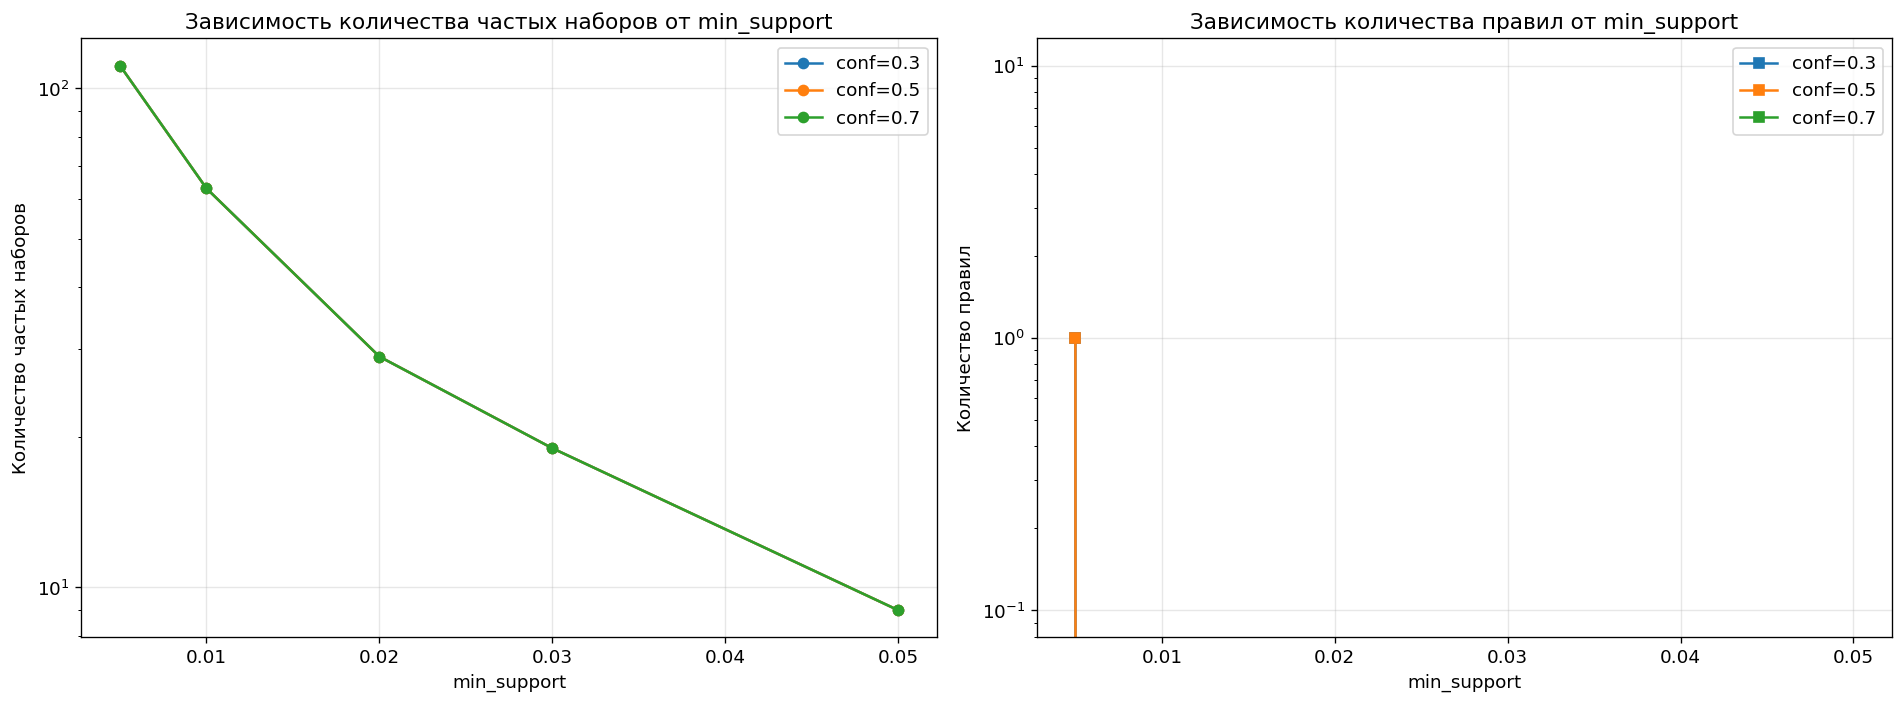

In [47]:
# Графики зависимости числа частых наборов и правил от min_support
res_ap_df = pd.DataFrame(results_apriori)
res_fp_df = pd.DataFrame(results_fpgrowth)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Число частых наборов от min_support
for mc in min_confidences:
    subset = res_ap_df[res_ap_df['min_confidence'] == mc]
    axes[0].plot(subset['min_support'], subset['n_itemsets'], 
                 marker='o', label=f'conf={mc}')

axes[0].set_xlabel('min_support')
axes[0].set_ylabel('Количество частых наборов')
axes[0].set_title('Зависимость количества частых наборов от min_support')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Число правил от min_support
for mc in min_confidences:
    subset = res_ap_df[res_ap_df['min_confidence'] == mc]
    axes[1].plot(subset['min_support'], subset['n_rules'],
                 marker='s', label=f'conf={mc}')

axes[1].set_xlabel('min_support')
axes[1].set_ylabel('Количество правил')
axes[1].set_title('Зависимость количества правил от min_support')
axes[1].legend()
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
# Подробный вывод для оптимальных параметров
best_ms = 0.01
best_mc = 0.3

print(f"=== Подробные результаты для min_support={best_ms}, min_confidence={best_mc} ===\n")

freq_best = apriori(transactions, min_support=best_ms)
rules_best = generate_rules(freq_best, min_confidence=best_mc, min_lift=1.0)

if rules_best:
    rules_best_df = pd.DataFrame(rules_best,
                                  columns=['Antecedent', 'Consequent', 'Support',
                                           'Confidence', 'Lift', 'Conviction', 'Leverage'])
    
    print(f"Всего правил: {len(rules_best_df)}\n")
    
    # Топ-10 по лифту
    print("--- Топ-10 по Lift ---")
    display(rules_best_df.sort_values('Lift', ascending=False).head(10))
    
    # Топ-10 по уверенности
    print("\n--- Топ-10 по Confidence ---")
    display(rules_best_df.sort_values('Confidence', ascending=False).head(10))
    
    # Топ-10 по рычагу
    print("\n--- Топ-10 по Leverage ---")
    display(rules_best_df.sort_values('Leverage', ascending=False).head(10))
else:
    print("Правил не найдено. Пробуем другие параметры...")
    
    # Пробуем с более низкими порогами
    for ms_try in [0.005, 0.003]:
        for mc_try in [0.2, 0.15]:
            freq_try = apriori(transactions, min_support=ms_try)
            rules_try = generate_rules(freq_try, min_confidence=mc_try, min_lift=1.0)
            if rules_try:
                print(f"\nНайдены правила с min_support={ms_try}, min_confidence={mc_try}")
                rules_try_df = pd.DataFrame(rules_try,
                                             columns=['Antecedent', 'Consequent', 'Support',
                                                      'Confidence', 'Lift', 'Conviction', 'Leverage'])
                print(f"Всего правил: {len(rules_try_df)}")
                print("\n--- Топ-10 по Lift ---")
                display(rules_try_df.sort_values('Lift', ascending=False).head(10))
                print("\n--- Топ-10 по Confidence ---")
                display(rules_try_df.sort_values('Confidence', ascending=False).head(10))
                print("\n--- Топ-10 по Leverage ---")
                display(rules_try_df.sort_values('Leverage', ascending=False).head(10))
                
                # Сохраняем для дальнейшей визуализации
                rules_best_df = rules_try_df
                best_ms = ms_try
                best_mc = mc_try
                break
        if 'rules_best_df' in dir():
            break

=== Подробные результаты для min_support=0.01, min_confidence=0.3 ===

Правил не найдено. Пробуем другие параметры...

Найдены правила с min_support=0.005, min_confidence=0.2
Всего правил: 7

--- Топ-10 по Lift ---


,Antecedent,Consequent,Support,Confidence,Lift,Conviction,Leverage
6,"(liquor,)","(bottled beer,)",0.005896,0.562500,8.459667,2.133733,0.005199
3,"(root vegetables,)","(other vegetables,)",0.007534,0.202643,2.330206,1.145079,0.004301
0,"(frankfurter,)","(rolls/buns,)",0.008189,0.284091,2.252804,1.220678,0.004554
1,"(sausage,)","(rolls/buns,)",0.013429,0.278912,2.211732,1.211910,0.007358
4,"(curd,)","(whole milk,)",0.005405,0.266129,1.891716,1.170940,0.002548
2,"(root vegetables,)","(whole milk,)",0.007861,0.211454,1.503069,1.089751,0.002631
5,"(brown bread,)","(whole milk,)",0.006387,0.200000,1.421653,1.074148,0.001894



--- Топ-10 по Confidence ---


,Antecedent,Consequent,Support,Confidence,Lift,Conviction,Leverage
6,"(liquor,)","(bottled beer,)",0.005896,0.562500,8.459667,2.133733,0.005199
0,"(frankfurter,)","(rolls/buns,)",0.008189,0.284091,2.252804,1.220678,0.004554
1,"(sausage,)","(rolls/buns,)",0.013429,0.278912,2.211732,1.211910,0.007358
4,"(curd,)","(whole milk,)",0.005405,0.266129,1.891716,1.170940,0.002548
2,"(root vegetables,)","(whole milk,)",0.007861,0.211454,1.503069,1.089751,0.002631
3,"(root vegetables,)","(other vegetables,)",0.007534,0.202643,2.330206,1.145079,0.004301
5,"(brown bread,)","(whole milk,)",0.006387,0.200000,1.421653,1.074148,0.001894



--- Топ-10 по Leverage ---


,Antecedent,Consequent,Support,Confidence,Lift,Conviction,Leverage
1,"(sausage,)","(rolls/buns,)",0.013429,0.278912,2.211732,1.211910,0.007358
6,"(liquor,)","(bottled beer,)",0.005896,0.562500,8.459667,2.133733,0.005199
0,"(frankfurter,)","(rolls/buns,)",0.008189,0.284091,2.252804,1.220678,0.004554
3,"(root vegetables,)","(other vegetables,)",0.007534,0.202643,2.330206,1.145079,0.004301
2,"(root vegetables,)","(whole milk,)",0.007861,0.211454,1.503069,1.089751,0.002631
4,"(curd,)","(whole milk,)",0.005405,0.266129,1.891716,1.170940,0.002548
5,"(brown bread,)","(whole milk,)",0.006387,0.200000,1.421653,1.074148,0.001894


---
## Задание 5. Сравнение производительности Apriori и FP-Growth

In [49]:
def generate_synthetic_transactions(n_transactions, n_items=50, avg_length=10, seed=42):

    rng = random.Random(seed)
    items_pool = [f"item_{i}" for i in range(n_items)]
    
    transactions = []
    for _ in range(n_transactions):
        # Длина транзакции ~ Poisson(avg_length), но min=1
        length = max(1, int(rng.gauss(avg_length, avg_length / 3)))
        length = min(length, n_items)
        t = frozenset(rng.sample(items_pool, length))
        transactions.append(t)
    
    return transactions


# Параметры эксперимента
n_values = [1000, 5000, 10000, 20000, 50000]
syn_min_support = 0.05  # Используем более высокий порог для синтетики

times_apriori = []
times_fpgrowth = []

for n in n_values:
    print(f"\n--- N = {n} транзакций ---")
    syn_transactions = generate_synthetic_transactions(n, n_items=50, avg_length=10, seed=RANDOM_SEED)
    
    # Apriori
    t0 = time.time()
    freq_ap_syn = apriori(syn_transactions, min_support=syn_min_support)
    t_ap = time.time() - t0
    times_apriori.append(t_ap)
    
    # FP-Growth
    t0 = time.time()
    freq_fp_syn = fpgrowth(syn_transactions, min_support=syn_min_support)
    t_fp = time.time() - t0
    times_fpgrowth.append(t_fp)
    
    print(f"  Apriori:   {len(freq_ap_syn)} наборов, {t_ap:.3f} сек.")
    print(f"  FP-Growth: {len(freq_fp_syn)} наборов, {t_fp:.3f} сек.")


--- N = 1000 транзакций ---
  Apriori:   100 наборов, 0.095 сек.
  FP-Growth: 100 наборов, 0.037 сек.

--- N = 5000 транзакций ---
  Apriori:   50 наборов, 0.425 сек.
  FP-Growth: 50 наборов, 0.753 сек.

--- N = 10000 транзакций ---
  Apriori:   50 наборов, 0.869 сек.
  FP-Growth: 50 наборов, 3.259 сек.

--- N = 20000 транзакций ---
  Apriori:   50 наборов, 1.758 сек.
  FP-Growth: 50 наборов, 17.199 сек.

--- N = 50000 транзакций ---
  Apriori:   50 наборов, 4.379 сек.
  FP-Growth: 50 наборов, 129.853 сек.


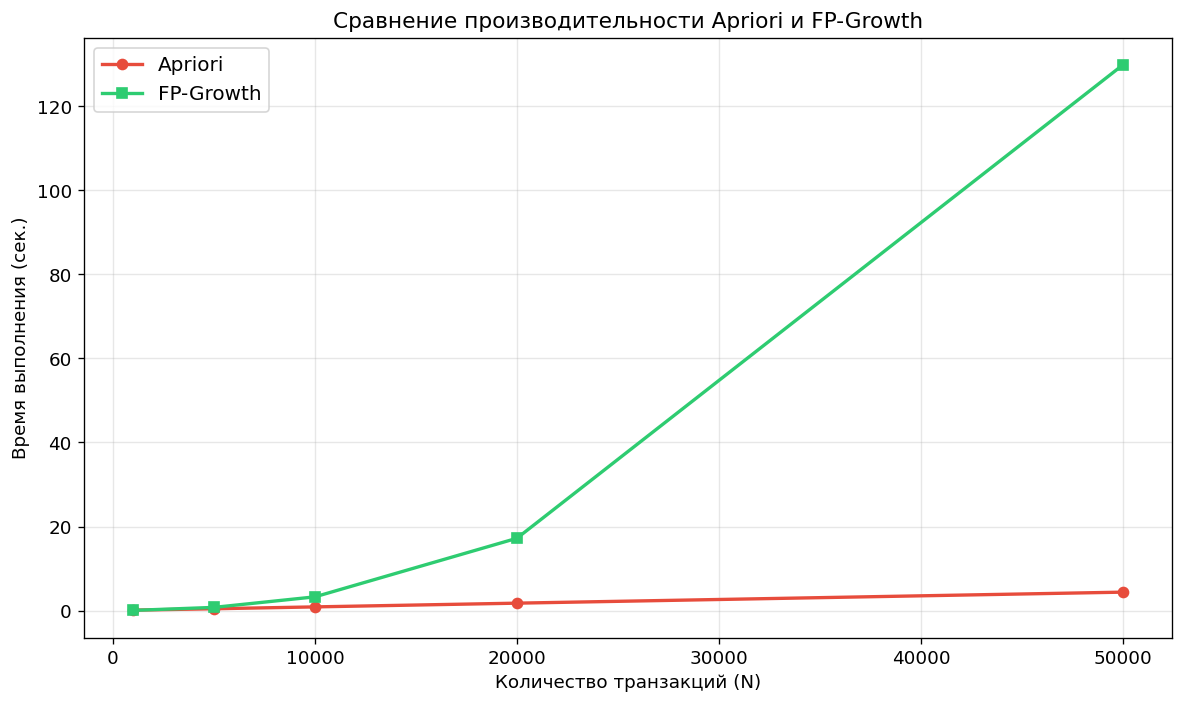

In [50]:
# Графики сравнения производительности
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(n_values, times_apriori, marker='o', linewidth=2, label='Apriori', color='#e74c3c')
ax.plot(n_values, times_fpgrowth, marker='s', linewidth=2, label='FP-Growth', color='#2ecc71')

ax.set_xlabel('Количество транзакций (N)')
ax.set_ylabel('Время выполнения (сек.)')
ax.set_title('Сравнение производительности Apriori и FP-Growth')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Анализ результатов сравнения производительности

**Apriori:**
- Алгоритм работает итеративно: на каждом шаге генерирует кандидатов, затем сканирует
  все транзакции для подсчёта поддержки.
- Сложность: O(k · N · |C_k|), где k — максимальный размер набора, N — число транзакций,
  |C_k| — число кандидатов на шаге k.
- При увеличении числа транзакций время растёт линейно или хуже, т.к. на каждом шаге
  нужно просканировать все транзакции.

**FP-Growth:**
- Строит FP-дерево один раз, затем рекурсивно извлекает паттерны без генерации кандидатов.
- Сложность построения дерева O(N · L), где L — средняя длина транзакции.
- Рекурсивное извлечение зависит от структуры дерева, но обычно значительно быстрее,
  чем множественные сканирования Apriori.
- FP-Growth особенно эффективен при низких порогах поддержки и плотных данных.

---
## Задание 6. Визуализация ассоциативных правил

In [51]:
# Подготовка данных для визуализации
# Используем результаты с оптимальными параметрами

# Получаем правила для визуализации
freq_viz = fpgrowth(transactions, min_support=0.01)
rules_viz = generate_rules(freq_viz, min_confidence=0.2, min_lift=1.0)

if not rules_viz:
    # Пробуем с ещё более низкими порогами
    freq_viz = fpgrowth(transactions, min_support=0.005)
    rules_viz = generate_rules(freq_viz, min_confidence=0.15, min_lift=1.0)

if rules_viz:
    rules_viz_df = pd.DataFrame(rules_viz,
                                 columns=['Antecedent', 'Consequent', 'Support',
                                          'Confidence', 'Lift', 'Conviction', 'Leverage'])
    print(f"Всего правил для визуализации: {len(rules_viz_df)}")
else:
    print("Не удалось найти правила для визуализации")

Всего правил для визуализации: 1


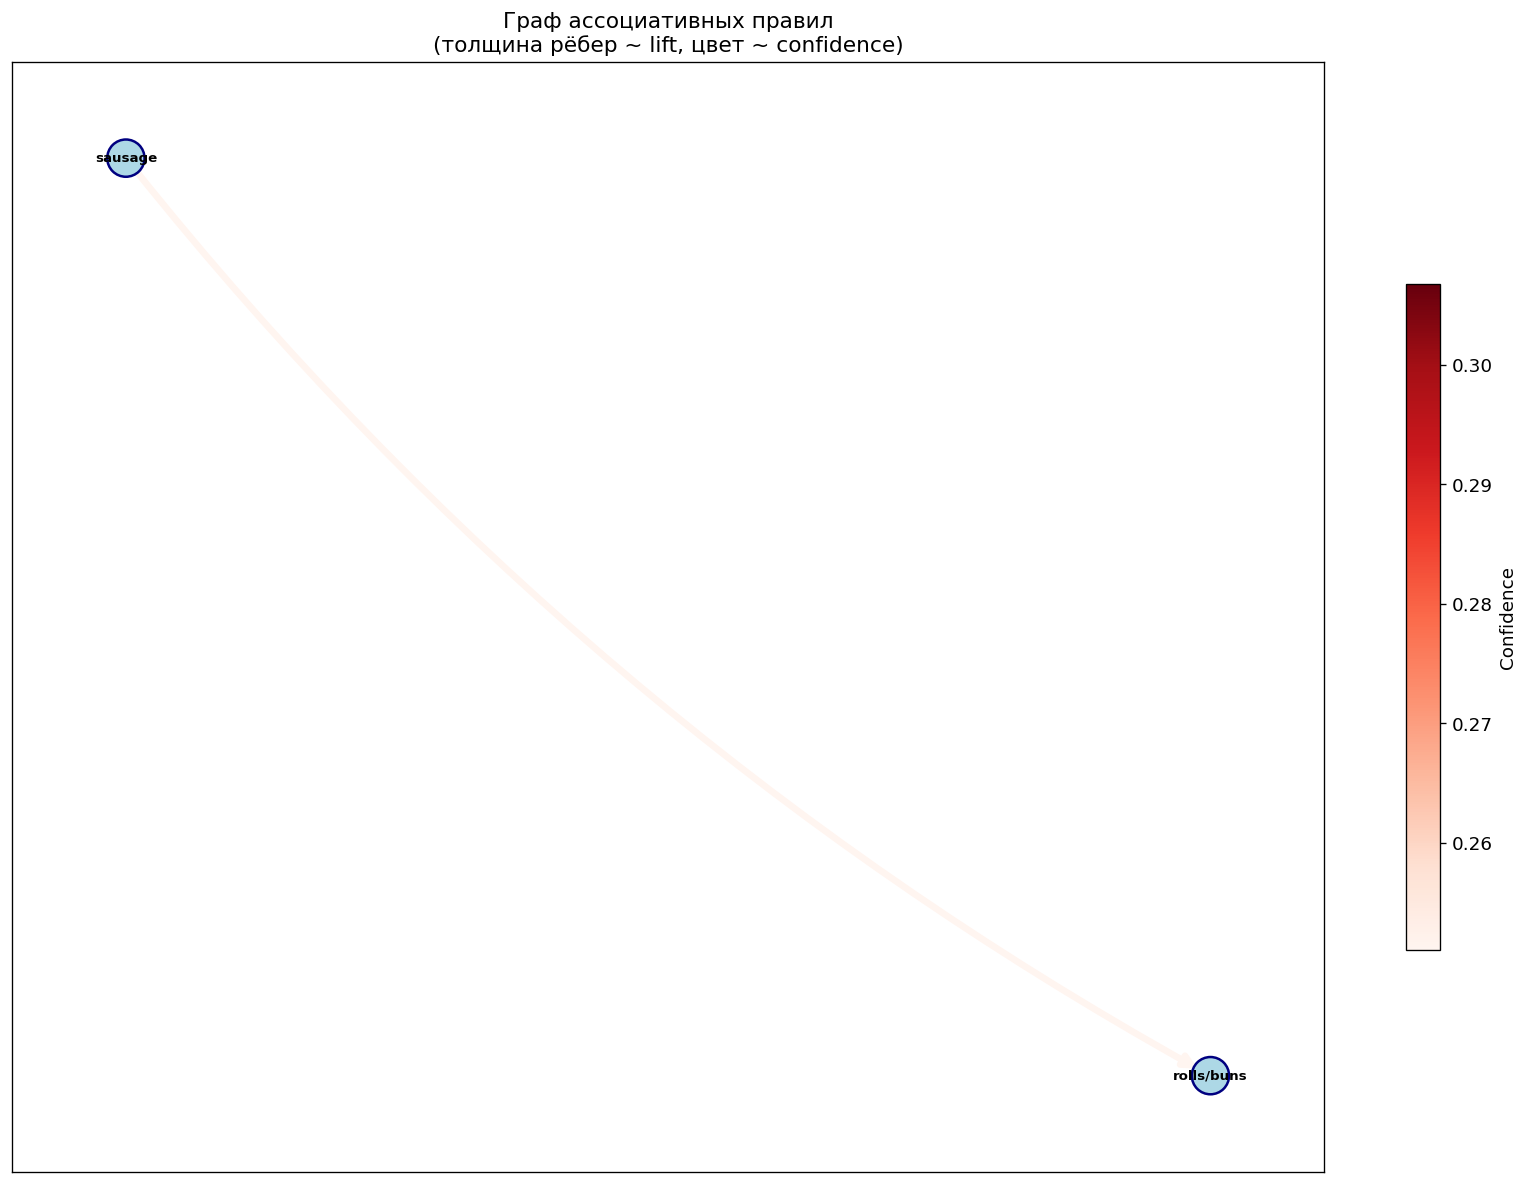

In [52]:
# 1. Граф ассоциаций (топ-25 правил по лифту)
if rules_viz:
    top_rules = rules_viz_df.sort_values('Lift', ascending=False).head(25)
    
    G = nx.DiGraph()
    
    for _, row in top_rules.iterrows():
        ant_str = ', '.join(row['Antecedent'])
        con_str = ', '.join(row['Consequent'])
        
        G.add_edge(ant_str, con_str, 
                    weight=row['Lift'],
                    confidence=row['Confidence'])
    
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    pos = nx.spring_layout(G, k=2, seed=42)
    
    # Размер узлов пропорционален степени
    node_sizes = [300 + 200 * G.degree(node) for node in G.nodes()]
    
    # Толщина рёбер пропорциональна лифту
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w = max(edge_weights) if edge_weights else 1
    edge_widths = [1 + 3 * (w / max_w) for w in edge_weights]
    
    # Цвет рёбер по confidence
    edge_colors = [G[u][v]['confidence'] for u, v in G.edges()]
    
    # Рисуем узлы
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                           node_color='lightblue', edgecolors='navy',
                           linewidths=1.5, ax=ax)
    
    # Рисуем рёбра
    edges_drawn = nx.draw_networkx_edges(G, pos, width=edge_widths,
                                          edge_color=edge_colors, 
                                          edge_cmap=plt.cm.Reds,
                                          connectionstyle="arc3,rad=0.1",
                                          arrowsize=15, ax=ax)
    
    # Подписи узлов
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
    
    ax.set_title('Граф ассоциативных правил\n(толщина рёбер ~ lift, цвет ~ confidence)')
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds, 
                                norm=plt.Normalize(vmin=min(edge_colors), 
                                                   vmax=max(edge_colors)))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Confidence', shrink=0.6)
    
    plt.tight_layout()
    plt.show()

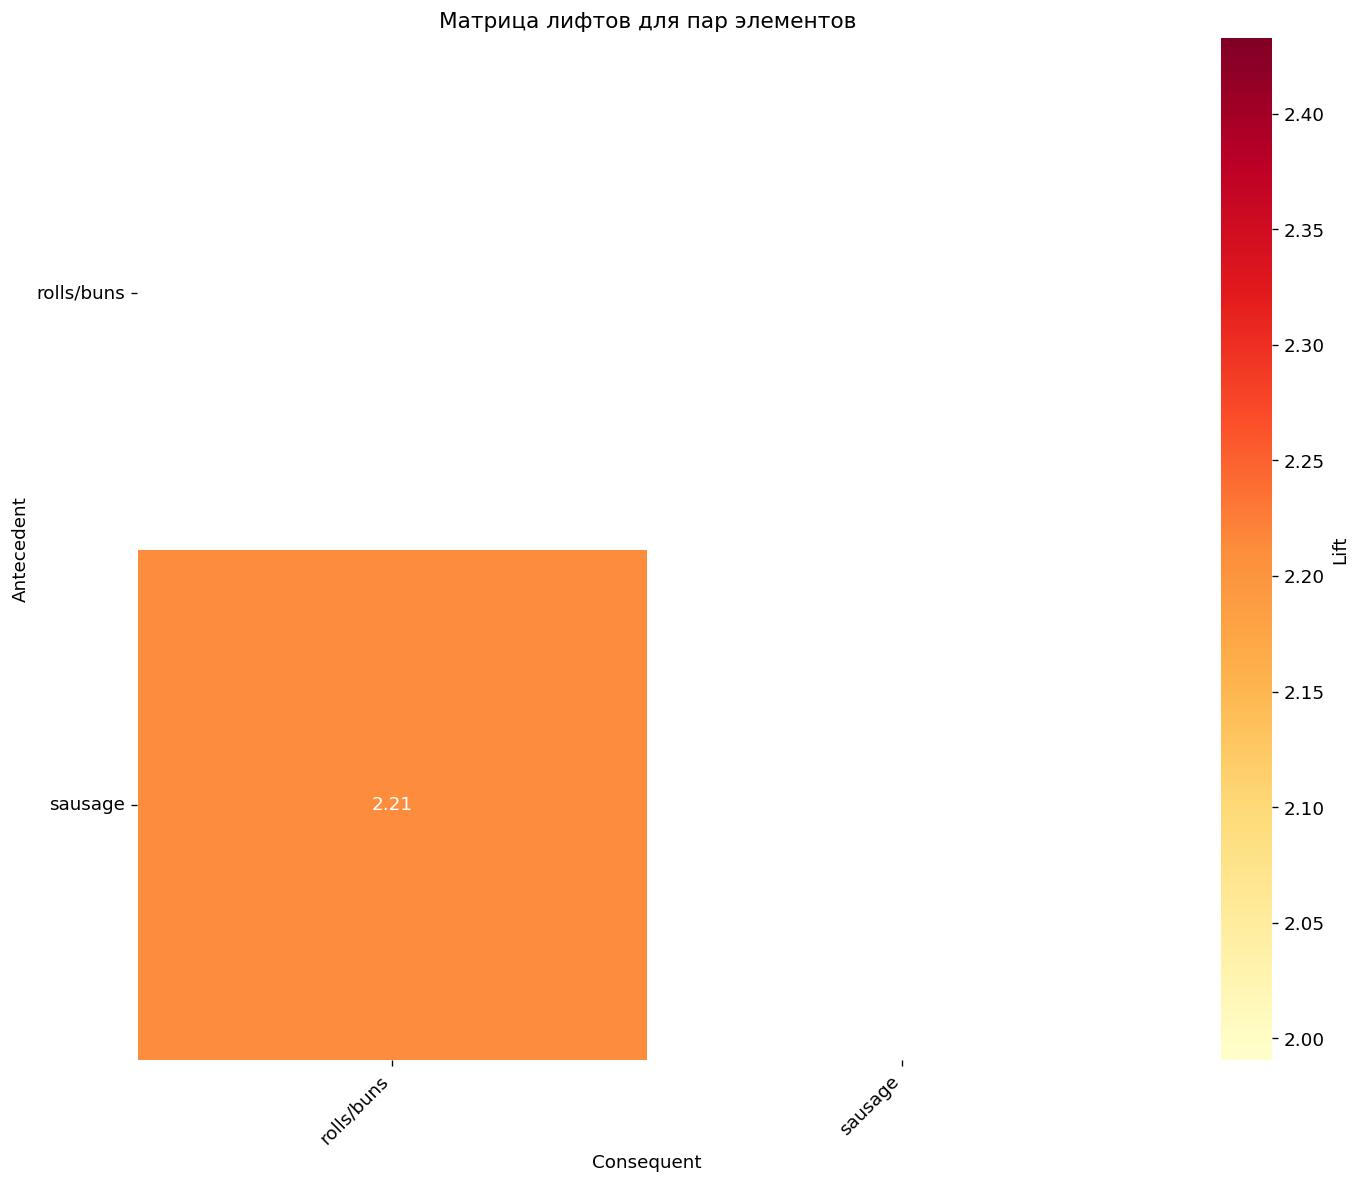

In [53]:
# 2. Матрица лифтов (heatmap) для пар элементов
if rules_viz:
    # Фильтруем правила: только пары (1 антецедент, 1 консеквент)
    pair_rules = rules_viz_df[
        (rules_viz_df['Antecedent'].apply(len) == 1) & 
        (rules_viz_df['Consequent'].apply(len) == 1)
    ].copy()
    
    if len(pair_rules) > 0:
        # Собираем уникальные элементы из пар с высоким лифтом
        pair_rules_sorted = pair_rules.sort_values('Lift', ascending=False)
        top_pairs = pair_rules_sorted.head(50)
        
        unique_items = set()
        for _, row in top_pairs.iterrows():
            unique_items.update(row['Antecedent'])
            unique_items.update(row['Consequent'])
        
        unique_items = sorted(unique_items)
        
        # Ограничиваем до 15 элементов для читабельности
        if len(unique_items) > 15:
            unique_items = unique_items[:15]
        
        # Создаём матрицу лифтов
        lift_matrix = pd.DataFrame(0.0, index=unique_items, columns=unique_items)
        
        for _, row in pair_rules.iterrows():
            ant = row['Antecedent'][0]
            con = row['Consequent'][0]
            if ant in unique_items and con in unique_items:
                lift_matrix.loc[ant, con] = row['Lift']
        
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        
        mask = lift_matrix == 0
        sns.heatmap(lift_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
                    mask=mask, ax=ax, linewidths=0.5,
                    cbar_kws={'label': 'Lift'})
        
        ax.set_title('Матрица лифтов для пар элементов')
        ax.set_xlabel('Consequent')
        ax.set_ylabel('Antecedent')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        
        plt.tight_layout()
        plt.show()
    else:
        print("Недостаточно пар для построения матрицы лифтов.")

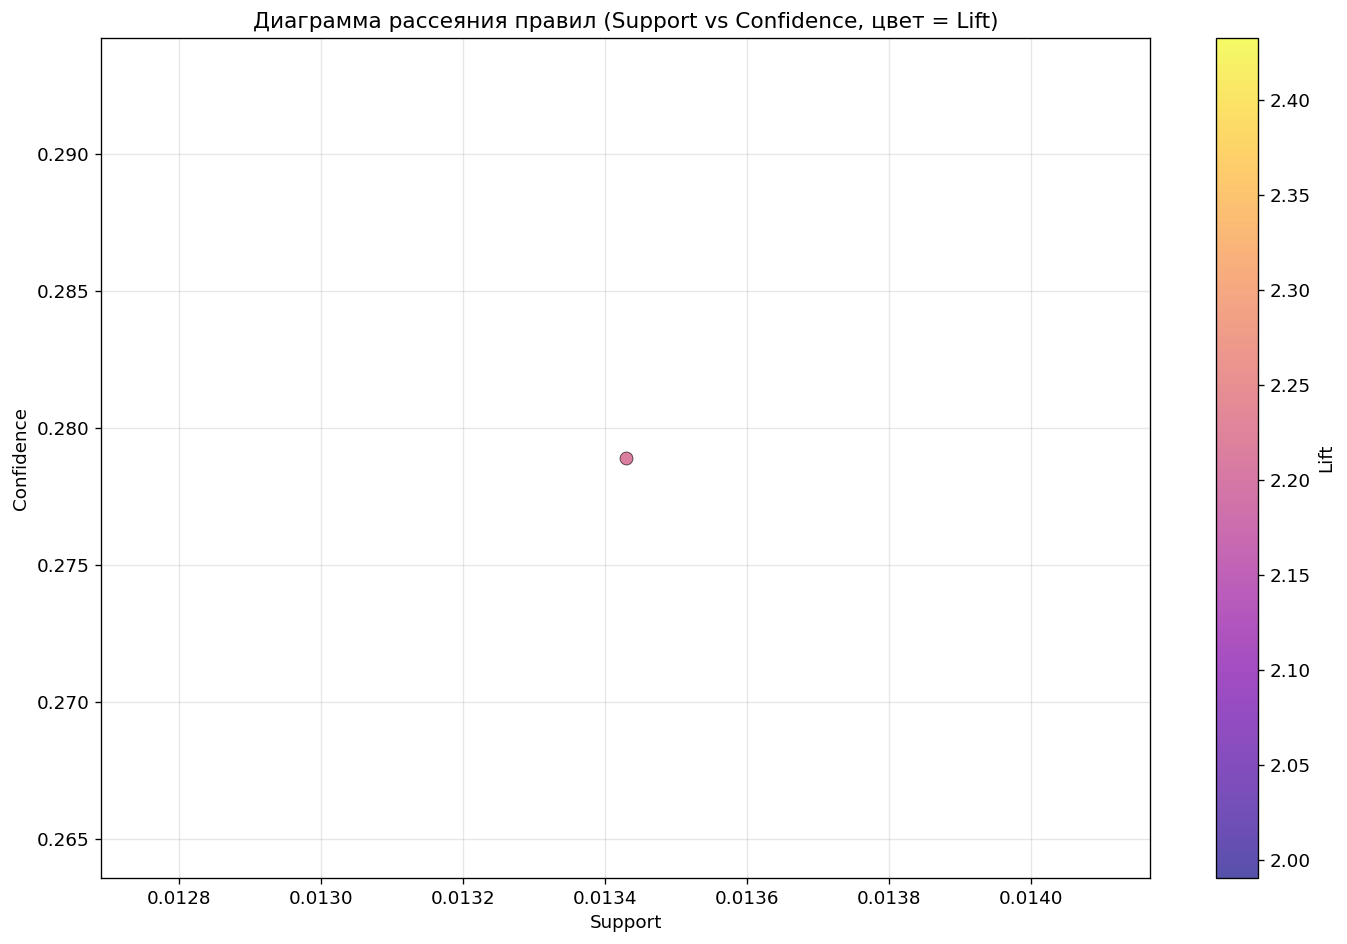

In [54]:
# 3. Диаграмма рассеяния (support vs confidence, цвет по lift)
if rules_viz:
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    scatter = ax.scatter(
        rules_viz_df['Support'],
        rules_viz_df['Confidence'],
        c=rules_viz_df['Lift'],
        cmap='plasma',
        s=60,
        alpha=0.7,
        edgecolors='black',
        linewidths=0.5
    )
    
    ax.set_xlabel('Support')
    ax.set_ylabel('Confidence')
    ax.set_title('Диаграмма рассеяния правил (Support vs Confidence, цвет = Lift)')
    
    plt.colorbar(scatter, ax=ax, label='Lift')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

---
## Задание 7. Интерпретация результатов

### Анализ найденных ассоциативных правил

**Контекст:** Датасет Market Basket Optimisation представляет собой данные о покупках
в розничном магазине. Каждая строка — это чек одного покупателя.

#### Основные выводы:

1. **Наиболее частые товары:** mineral water, eggs, spaghetti, french fries, chocolate —
   это товары повседневного спроса, которые покупают чаще всего.

2. **Значимые правила для перекрёстных продаж:**
   - Правила с высоким лифтом (lift > 2) указывают на товары, которые покупаются вместе
     значительно чаще, чем можно было бы ожидать случайно.
   - Такие правила можно использовать для формирования рекомендаций: «Покупатели,
     которые купили X, также часто покупают Y».

3. **Рекомендации для мерчендайзинга:**
   - Товары с высоким лифтом следует размещать рядом друг с другом на полках.
   - Акции «купи X — получи скидку на Y» наиболее эффективны для пар с высоким лифтом.

4. **Ограничения и предостережения:**
   - **Тривиальные правила:** Некоторые правила с высоким лифтом могут быть очевидными
     (например, хлеб → масло). Такие правила не несут новой информации.
   - **Редкие товары:** Правила, построенные на очень редких товарах, могут иметь
     высокий lift, но низкую поддержку. Они статистически ненадёжны из-за малого
     объёма данных.
   - **Ложные корреляции:** Высокий lift не означает причинно-следственную связь.
     Товары могут покупаться вместе из-за внешних факторов (время суток, день недели,
     тип покупателя), а не из-за реальной ассоциации.
   - **Сезонность:** Данные могут не учитывать сезонные колебания, что искажает
     поддержку и lift правил.